# Introduction to rosaceAA (Python)

This vignette replicates the [rosaceAA R vignette](https://github.com/pimentellab/rosace-aa/blob/main/vignettes/intro_rosaceAA.Rmd) in Python using the `rosace` package.

rosaceAA extends the base ROSACE model with position-level shrinkage and BLOSUM62-based amino acid grouping,
enabling prior information about substitution biochemistry to inform variant effect estimates.

## Four ROSACE models

| Model | Extra structure | Key Stan data |
|-------|-----------------|---------------|
| **ROSACE0** | None — independent variant scores | — |
| **ROSACE1** | Position-level grouping | `vMAPp`, `P` |
| **ROSACE2** | Position + global BLOSUM62 group | `vMAPp`, `P`, `vMAPb`, `B` |
| **ROSACE3** | Position + BLOSUM62 + position-specific activation | same as ROSACE2 + `rho` |

We use the **OCT1 drug cytotoxicity screen** throughout, mirroring the R vignette.


## Installation

```bash
pip install rosace
```

CmdStan (required for Bayesian MCMC inference) can be installed via:
```python
import cmdstanpy
cmdstanpy.install_cmdstan()
```


In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import os
import re
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rdata

from rosace.assay import AssayGrowth, AssaySetGrowth
from rosace.preprocessing import filter_data, impute_data, normalize_data
from rosace.run_rosace import run_rosace
from rosace.utils import output_score, map_blosum_score
from rosace.visualization import score_density


## Install CmdStan

The cell below installs CmdStan if it is not already present.  Skip it if you have already installed CmdStan.


In [2]:
import cmdstanpy

# Install CmdStan if not already present
cmdstanpy.install_cmdstan(overwrite=False, verbose=True)


CmdStan install directory: /home/runner/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation



--- Translating Stan model to C++ code ---
bin/stanc  --o=examples/bernoulli/bernoulli.hpp examples/bernoulli/bernoulli.stan

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.87.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS          -c -Wno-ignored-attributes   -x c++ -o examples/bernoulli/bernoulli.o examples/bernoulli/bernoulli.hpp



--- Linking model ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.87.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS               -Wl,-L,"/home/runner/.cmdstan/cmdstan-2.38.0/stan/lib/stan_math/lib/tbb"   -Wl,-rpath,"/home/runner/.cmdstan/cmdstan-2.38.0/stan/lib/stan_math/lib/tbb"      examples/bernoulli/bernoulli.o src/cmdstan/main.o       -ltbb   stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_nvecserial.a stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_cvodes.a stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_idas.a stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_kinsol.a  stan/lib/stan_math/lib/tbb/libtb

True

## Read count data

The OCT1 drug cytotoxicity screen has **three replicates**.  Each replicate is stored as a DataFrame in `oct1.rda`.

| Object | Columns | Timepoints |
|--------|---------|------------|
| `oct1_rep1` | hgvs, c_0, c_2, c_4, c_6 | 4 |
| `oct1_rep2` | hgvs, c_0, c_2, c_4, c_6 | 4 |
| `oct1_rep3` | hgvs, c_0, c_2, c_4 | 3 |


In [3]:
# Locate the .rda file relative to this notebook
notebook_dir = Path(".").resolve()
repo_root = notebook_dir.parent
rda_src = repo_root / "data" / "R" / "oct1.rda"

# Copy to a temporary directory so we work from a clean location
tmp_dir = Path(tempfile.mkdtemp())
rda_path = shutil.copy(str(rda_src), str(tmp_dir))
print(f"Working copy: {rda_path}")

# Read all objects from the .rda file
oct1_data = rdata.read_rda(rda_path)
print(f"Objects in .rda: {list(oct1_data.keys())}")

key = "OCT1"
type_ = "growth"


Working copy: /tmp/tmp434tvg8q/oct1.rda


Objects in .rda: ['oct1_rep1', 'oct1_rep2', 'oct1_rep3']


## Create Assay objects

Each replicate becomes an `AssayGrowth`.  The `key` ties replicates together (mirrors the R `key = "1SM73"`).


In [4]:
def make_assay(df_raw: pd.DataFrame, rep: int) -> AssayGrowth:
    """Convert a replicate DataFrame from oct1.rda into an AssayGrowth."""
    df = df_raw.copy()
    df.columns = [str(c) for c in df.columns]
    count_cols = [c for c in df.columns if c.startswith("c_")]
    return AssayGrowth(
        counts=df[count_cols].values.astype(float),
        var_names=df["hgvs"].tolist(),
        key=key,
        rep=rep,
    )


assay1 = make_assay(oct1_data["oct1_rep1"], rep=1)
assay2 = make_assay(oct1_data["oct1_rep2"], rep=2)
assay3 = make_assay(oct1_data["oct1_rep3"], rep=3)

for a in [assay1, assay2, assay3]:
    print(f"Replicate {a.rep}: {a.counts.shape[0]} variants × {a.counts.shape[1]} timepoints")


Replicate 1: 11440 variants × 4 timepoints
Replicate 2: 11453 variants × 4 timepoints
Replicate 3: 11424 variants × 3 timepoints


## Preprocessing

### Filter
`filter_data` removes variants with too many NAs or too few total counts (mirrors R `FilterData`).


In [5]:
filtered_assays = []
for a in [assay1, assay2, assay3]:
    fa = filter_data(a, na_rmax=0.5, min_count=20)
    print(f"Rep {a.rep}: {a.counts.shape[0]} → {fa.counts.shape[0]} variants after filtering")
    filtered_assays.append(fa)


Rep 1: 11440 → 11176 variants after filtering
Rep 2: 11453 → 11283 variants after filtering
Rep 3: 11424 → 11071 variants after filtering


### Impute

`impute_data` fills remaining NAs.  We use K-nearest neighbours (KNN) imputation to match the R vignette (`ImputeData(impute.method = "knn")`).


In [6]:
# KNN imputation mirrors the R vignette default
imputed_assays = [impute_data(a, method="knn") for a in filtered_assays]
print("KNN imputation complete.")


KNN imputation complete.


### Normalize

`normalize_data` computes log-ratio growth scores relative to the wildtype controls (mirrors R `NormalizeData(normalization.method = "wt")`).


In [7]:
norm_assays = []
for a in imputed_assays:
    na = normalize_data(a, method="wt", wt_var_names=["_wt"], wt_rm=True)
    print(f"Rep {a.rep}: {na.norm_counts.shape[0]} variants after wt-normalisation")
    norm_assays.append(na)


Rep 1: 11175 variants after wt-normalisation
Rep 2: 11282 variants after wt-normalisation
Rep 3: 11070 variants after wt-normalisation


### Integrate replicates

Combine the three normalised replicates into an `AssaySetGrowth` via outer join (mirrors R `IntegrateData`).


In [8]:
def integrate_replicates(assays: list[AssayGrowth]) -> AssaySetGrowth:
    """Integrate any number of normalized AssayGrowth objects via outer join."""

    def norm_df(a: AssayGrowth) -> pd.DataFrame:
        names = a.norm_var_names or a.var_names
        T = a.norm_counts.shape[1]
        return pd.DataFrame(
            a.norm_counts, index=names,
            columns=[f"r{a.rep}_t{t}" for t in range(T)],
        )

    def raw_df(a: AssayGrowth) -> pd.DataFrame:
        T = a.counts.shape[1]
        return pd.DataFrame(
            a.counts, index=a.var_names,
            columns=[f"r{a.rep}_raw_t{t}" for t in range(T)],
        )

    combined = norm_df(assays[0])
    for a in assays[1:]:
        combined = combined.join(norm_df(a), how="outer")

    raw_combined = raw_df(assays[0])
    for a in assays[1:]:
        raw_combined = raw_combined.join(raw_df(a), how="outer")

    return AssaySetGrowth(
        combined_counts=combined.values,
        var_names=list(combined.index),
        reps=[a.rep for a in assays],
        key=assays[0].key,
        raw_counts=raw_combined.values,
        rounds=[a.rounds for a in assays],
    )


rosace_set = integrate_replicates(norm_assays)
print(
    f"AssaySetGrowth: {rosace_set.combined_counts.shape[0]} variants, "
    f"{rosace_set.combined_counts.shape[1]} columns "
    f"(reps {rosace_set.reps}, rounds per rep: {rosace_set.rounds})"
)


AssaySetGrowth: 11305 variants, 11 columns (reps [1, 2, 3], rounds per rep: [3, 3, 2])


## Process variant metadata

Parse HGVS-style names like `p.(A107C)` into `position`, `wildtype`, `mutation`, and `type` (mirrors R `rosace@var.data` manipulation in the vignette).


In [9]:
_HGVS_RE = re.compile(r"p\.\(([A-Z])(\d+)([A-Z])\)")


def parse_hgvs(hgvs: str) -> tuple:
    """Return (wildtype, position, mutation, type) from an HGVS protein name."""
    m = _HGVS_RE.match(hgvs)
    if m:
        wt, pos, mut = m.group(1), int(m.group(2)), m.group(3)
        vtype = "synonymous" if wt == mut else "missense"
        return wt, pos, mut, vtype
    if "del" in hgvs:
        return None, None, None, "deletion"
    return None, None, None, "other"


parsed = [parse_hgvs(v) for v in rosace_set.var_names]
var_data = pd.DataFrame(
    parsed,
    columns=["wildtype", "position", "mutation", "type"],
    index=rosace_set.var_names,
).rename_axis("variants").reset_index()

print("Variant type distribution:")
print(var_data["type"].value_counts())
var_data.head()


Variant type distribution:
type
missense      10261
deletion        528
synonymous      516
Name: count, dtype: int64


,variants,wildtype,position,mutation,type
0,p.(A107A),A,107.0,A,synonymous
1,p.(A107C),A,107.0,C,missense
2,p.(A107D),A,107.0,D,missense
3,p.(A107E),A,107.0,E,missense
4,p.(A107F),A,107.0,F,missense


## Subset for vignette

For this vignette we run on the first **1 000 variants** of the integrated assay set — matching the structure of the R vignette (which uses 100).
Remove the slicing to run the full dataset (may take an hour).


In [10]:
# ---- ROSACE0 test set: first 1000 of all variant types ----
N = 1000
all_idx = list(range(min(N, len(rosace_set.var_names))))
assay_test0 = AssaySetGrowth(
    combined_counts=rosace_set.combined_counts[all_idx],
    var_names=[rosace_set.var_names[i] for i in all_idx],
    reps=rosace_set.reps,
    key=rosace_set.key,
    raw_counts=rosace_set.raw_counts[all_idx] if rosace_set.raw_counts is not None else None,
    rounds=rosace_set.rounds,
)

# ---- ROSACE1/2/3 test set: first 1000 missense variants ----
var_info_full = (
    var_data[var_data["type"] == "missense"]
    .rename(columns={"position": "pos", "variants": "variant"})
    [["variant", "pos", "wildtype", "mutation"]]
    .rename(columns={"wildtype": "wt", "mutation": "mut"})
    .copy()
)
var_info_full["pos"] = var_info_full["pos"].astype(int)

missense_set = set(var_info_full["variant"])
missense_idx = [i for i, v in enumerate(rosace_set.var_names) if v in missense_set]

assay_missense = AssaySetGrowth(
    combined_counts=rosace_set.combined_counts[missense_idx],
    var_names=[rosace_set.var_names[i] for i in missense_idx],
    reps=rosace_set.reps,
    key=rosace_set.key,
    raw_counts=rosace_set.raw_counts[missense_idx] if rosace_set.raw_counts is not None else None,
    rounds=rosace_set.rounds,
)

keep_vars = assay_missense.var_names[:N]
keep_set = set(keep_vars)
var_info_test = var_info_full[var_info_full["variant"].isin(keep_set)].copy()
m_idx = [i for i, v in enumerate(assay_missense.var_names) if v in keep_set]
assay_test = AssaySetGrowth(
    combined_counts=assay_missense.combined_counts[m_idx],
    var_names=[assay_missense.var_names[i] for i in m_idx],
    reps=assay_missense.reps,
    key=assay_missense.key,
    raw_counts=assay_missense.raw_counts[m_idx] if assay_missense.raw_counts is not None else None,
    rounds=assay_missense.rounds,
)

print(f"ROSACE0 assay:     {assay_test0.combined_counts.shape[0]} variants")
print(f"ROSACE1/2/3 assay: {assay_test.combined_counts.shape[0]} missense variants")
print(f"var_info_test:     {len(var_info_test)} rows, {var_info_test['pos'].nunique()} positions")


ROSACE0 assay:     1000 variants
ROSACE1/2/3 assay: 1000 missense variants
var_info_test:     1000 rows, 53 positions


## Run ROSACE

There are **four model variants**, matching the `rosaceAA` R package. All are fitted with `run_rosace()`.

### Model 0 — no positional structure

The simplest model: each variant gets its own fitness score with no position- or amino-acid-level pooling (equivalent to `RunRosace` with no `pos.col` in R).


In [11]:
# Model 0 – run on AssaySetGrowth with all variant types
score_model0 = run_rosace(
    assay_test0,
    method="ROSACE0",
    chains=4,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=42,
)
print(f"ROSACE0  |  variants: {len(score_model0.score)}")
print(score_model0.score.describe())


03:06:26 - cmdstanpy - INFO - compiling stan file /tmp/tmpsp7ch43o.stan to exe file /tmp/tmpsp7ch43o


03:06:35 - cmdstanpy - INFO - compiled model executable: /tmp/tmpsp7ch43o


03:06:35 - cmdstanpy - INFO - CmdStan start processing


03:06:35 - cmdstanpy - INFO - Chain [1] start processing


03:06:35 - cmdstanpy - INFO - Chain [2] start processing


...

03:08:23 - cmdstanpy - INFO - Chain [3] done processing


03:08:44 - cmdstanpy - INFO - Chain [1] done processing


03:08:44 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpsp7ch43o.stan', line 20, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpsp7ch43o.stan', line 20, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpsp7ch43o.stan', line 20, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpsp7ch43o.stan', line 20, column 4 to column 64)
Consider re-running with show_console=True if the above output is unclear!


03:08:44 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 51 iterations at max treedepth (10.2%)
	Chain 3 had 35 iterations at max treedepth (7.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


ROSACE0  |  variants: 1000
              mean           sd          lfsr
count  1000.000000  1000.000000  1.000000e+03
mean      0.228552     0.265510  6.916175e-02
std       0.991046     0.020935  1.203057e-01
min      -1.840254     0.221555  1.389868e-20
25%      -0.579190     0.249624  8.068752e-07
50%      -0.037151     0.265071  3.351060e-03
75%       1.129045     0.281248  8.918249e-02
max       2.329884     0.319532  4.979926e-01


### Model 1 — position-level grouping

A position-level hyperprior pools information across all variants at the same amino-acid position.  Equivalent to `RunRosace(pos.col = "position")` in R.

```
beta[v] = phi[vMAPp[v]] + eta2[v] * sqrt(sigma2[vMAPp[v]])
m[v,t]  ~ N(b[v] + beta[v]*t,  sqrt(epsilon2[vMAPm[v]]))
```


In [12]:
# Model 1 – requires var_info (missense variants only)
score_model1 = run_rosace(
    assay_test,
    method="ROSACE1",
    var_info=var_info_test,
    chains=4,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=42,
)
print(f"ROSACE1  |  variants: {len(score_model1.score)}, positions: {len(score_model1.optional_score)}")
print(score_model1.score.describe())


03:08:45 - cmdstanpy - INFO - compiling stan file /tmp/tmpae40ksr2.stan to exe file /tmp/tmpae40ksr2


03:08:54 - cmdstanpy - INFO - compiled model executable: /tmp/tmpae40ksr2


03:08:54 - cmdstanpy - INFO - CmdStan start processing


03:08:54 - cmdstanpy - INFO - Chain [1] start processing


03:08:54 - cmdstanpy - INFO - Chain [2] start processing


...

03:09:58 - cmdstanpy - INFO - Chain [1] done processing


03:10:00 - cmdstanpy - INFO - Chain [2] done processing


03:10:03 - cmdstanpy - INFO - Chain [4] done processing


03:10:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpae40ksr2.stan', line 32, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpae40ksr2.stan', line 32, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpae40ksr2.stan', line 32, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmpae40ksr2.stan', line 32, column 4 to column 64)
Consider re-running with show_console=True if the above output is unclear!


ROSACE1  |  variants: 1000, positions: 53
              mean           sd          lfsr
count  1000.000000  1000.000000  1.000000e+03
mean      0.198804     0.260111  6.683834e-02
std       0.994401     0.019777  1.173521e-01
min      -1.810538     0.203750  8.564307e-24
25%      -0.593001     0.246538  1.382317e-06
50%      -0.099948     0.259724  2.849554e-03
75%       1.063698     0.275884  7.497326e-02
max       2.358470     0.315317  4.997094e-01


### Model 2 — position + global BLOSUM62 group (rosaceAA)

Adds a **global** BLOSUM62 substitution-score group (`vMAPb`) on top of position shrinkage. Substitutions with similar BLOSUM62 scores share a hyperprior, encoding the biochemical expectation that similar substitutions have similar effects. Equivalent to `RunRosace(wt.col, mut.col, aa.code = "single", pos.act = FALSE)` in R.

```
beta[v] = phi[p] + psi[b] + eta2[v]*sqrt(sigma2[p]) + eta3[v]*sqrt(tau2[b])
```


In [13]:
# Model 2 – rosaceAA: position + BLOSUM90 group (weighted sum-to-zero contrast)
score_model2 = run_rosace(
    assay_test,
    method="ROSACE2",
    var_info=var_info_test,
    chains=4,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=42,
)
print(f"ROSACE2  |  variants: {len(score_model2.score)}, BLOSUM groups B={len(score_model2.misc['blosum_scores'])}")
print(score_model2.score.describe())


03:10:04 - cmdstanpy - INFO - compiling stan file /tmp/tmp6yvdiu2x.stan to exe file /tmp/tmp6yvdiu2x


03:10:16 - cmdstanpy - INFO - compiled model executable: /tmp/tmp6yvdiu2x


03:10:16 - cmdstanpy - INFO - CmdStan start processing


03:10:16 - cmdstanpy - INFO - Chain [1] start processing


03:10:16 - cmdstanpy - INFO - Chain [2] start processing


...

03:11:42 - cmdstanpy - INFO - Chain [3] done processing


03:11:43 - cmdstanpy - INFO - Chain [2] done processing


03:11:44 - cmdstanpy - INFO - Chain [4] done processing


03:11:44 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6yvdiu2x.stan', line 65, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6yvdiu2x.stan', line 65, column 4 to column 64)
Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'tmp6yvdiu2x.stan', line 65, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6yvdiu2x.stan', line 65, column 4 to column 64)
Consider re-running with show_console=True if the above output is unclear!


ROSACE2  |  variants: 1000, BLOSUM groups B=6
              mean           sd          lfsr
count  1000.000000  1000.000000  1.000000e+03
mean      0.198653     0.260143  6.759084e-02
std       0.994903     0.018161  1.191498e-01
min      -1.827317     0.208743  4.946325e-23
25%      -0.613967     0.247063  9.723396e-07
50%      -0.095085     0.260074  2.673306e-03
75%       1.079785     0.273598  7.349106e-02
max       2.356738     0.318925  4.978586e-01


### Model 3 — position + BLOSUM62 + activation (rosaceAA)

Adds a global activation fraction `rho ∈ (0,1)` that scales the entire signal. Equivalent to `RunRosace(..., pos.act = TRUE)` in R.

```
beta[v] = rho * (phi[p] + psi[b] + eta2[v]*sqrt(sigma2[p]) + eta3[v]*sqrt(tau2[b]))
rho ~ Beta(2, 2)
```


In [14]:
# Model 3 – rosaceAA: position + BLOSUM90 group + per-position activation fraction rho
score_model3 = run_rosace(
    assay_test,
    method="ROSACE3",
    var_info=var_info_test,
    chains=4,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=42,
)
print(f"ROSACE3  |  variants: {len(score_model3.score)}, rho positions: {len(score_model3.misc['rho_scores'])}")
print(score_model3.score.describe())


03:11:45 - cmdstanpy - INFO - compiling stan file /tmp/tmp6b3rh4xm.stan to exe file /tmp/tmp6b3rh4xm


03:11:58 - cmdstanpy - INFO - compiled model executable: /tmp/tmp6b3rh4xm


03:11:58 - cmdstanpy - INFO - CmdStan start processing


03:11:58 - cmdstanpy - INFO - Chain [1] start processing


03:11:58 - cmdstanpy - INFO - Chain [2] start processing


...

03:13:25 - cmdstanpy - INFO - Chain [3] done processing


03:13:27 - cmdstanpy - INFO - Chain [1] done processing


03:13:29 - cmdstanpy - INFO - Chain [2] done processing


03:13:29 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6b3rh4xm.stan', line 67, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6b3rh4xm.stan', line 67, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6b3rh4xm.stan', line 67, column 4 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'tmp6b3rh4xm.stan', line 67, column 4 to column 64)
Consider re-running with show_console=True if the above output is unclear!


ROSACE3  |  variants: 1000, rho positions: 53
              mean           sd          lfsr
count  1000.000000  1000.000000  1.000000e+03
mean      0.198324     0.259329  6.673923e-02
std       0.995804     0.018913  1.187097e-01
min      -1.848547     0.206766  1.283483e-23
25%      -0.621428     0.246093  8.756550e-07
50%      -0.091237     0.259941  2.400794e-03
75%       1.084780     0.273600  7.134322e-02
max       2.368336     0.313576  4.938956e-01


## Output scores

The `output_score` function extracts the **variant-level** scores from a `Score` object and adds hypothesis-test labels using the local false sign rate (LFSR). This mirrors R's `OutputScore` function.

| LFSR | Label |
|------|-------|
| ≥ 0.05 | Neutral |
| < 0.05, mean > 0 | Pos |
| < 0.05, mean ≤ 0 | Neg |

For **ROSACE1/2/3**, `score.optional_score` contains the position-level `phi` scores, equivalent to R's `OutputScore(pos.info = TRUE)$df_position`.


In [15]:
# --- Variant-level scores (all models) ---
scores_model0 = output_score(score_model0, sig_test=0.05)
scores_model1 = output_score(score_model1, sig_test=0.05)
scores_model2 = output_score(score_model2, sig_test=0.05)
scores_model3 = output_score(score_model3, sig_test=0.05)

for name, sc in [("ROSACE0", scores_model0), ("ROSACE1", scores_model1),
                  ("ROSACE2", scores_model2), ("ROSACE3", scores_model3)]:
    cnts = sc["label"].value_counts().to_dict()
    print(f"{name}: Neg={cnts.get('Neg',0):4d}  Neutral={cnts.get('Neutral',0):4d}  "
          f"Pos={cnts.get('Pos',0):4d}")


ROSACE0: Neg= 267  Neutral= 376  Pos= 357
ROSACE1: Neg= 313  Neutral= 343  Pos= 344
ROSACE2: Neg= 301  Neutral= 355  Pos= 344
ROSACE3: Neg= 306  Neutral= 344  Pos= 350


In [16]:
# ROSACE0 variant scores
print("ROSACE0 variant scores (head):")
display(scores_model0.head())


ROSACE0 variant scores (head):


,variant,mean,sd,lfsr,label
0,p.(A107A),-0.315343,0.251548,0.104992,Neutral
1,p.(A107C),0.168087,0.254985,0.254883,Neutral
2,p.(A107D),0.442379,0.248302,0.037406,Neutral
3,p.(A107E),-0.668957,0.248737,0.003579,Neg
4,p.(A107F),-0.100709,0.242601,0.339026,Neutral


In [17]:
# ROSACE1 variant scores + position-level scores
# Equivalent to OutputScore(pos.info = TRUE) in R
df_variant_model1 = scores_model1.copy()
df_position_model1 = score_model1.optional_score.copy()

print("ROSACE1 variant scores (head):")
display(df_variant_model1.head())

print("\nROSACE1 position scores (head):")
display(df_position_model1.head())


ROSACE1 variant scores (head):


,variant,mean,sd,lfsr,label
0,p.(A107C),0.112101,0.237700,0.318603,Neutral
1,p.(A107D),0.347016,0.245080,0.078399,Neutral
2,p.(A107E),-0.665625,0.229731,0.001881,Neg
3,p.(A107F),-0.141766,0.281082,0.307004,Neutral
4,p.(A107G),-1.030777,0.258514,0.000033,Neg



ROSACE1 position scores (head):


,pos,mean,sd
0,107,-0.347254,0.161874
1,110,-0.629917,0.151223
2,143,-0.325622,0.146636
3,157,0.475249,0.262340
4,170,1.110001,0.197546


In [18]:
# ROSACE2 variant scores + position-level scores
# Equivalent to OutputScore(pos.info = TRUE, blosum.info = TRUE) in R
df_variant_model2 = scores_model2.copy()
df_variant_model2 = df_variant_model2.merge(
    var_info_test[["variant", "pos", "wt", "mut"]], on="variant", how="left"
)
# Add BLOSUM90 score annotation (map_blosum_score now returns BLOSUM90 raw score,
# capped at 5, matching R's MapBlosumScore)
df_variant_model2["blosum_score"] = df_variant_model2.apply(
    lambda r: map_blosum_score(str(r["wt"]), str(r["mut"]))
              if pd.notna(r["wt"]) and pd.notna(r["mut"]) else None,
    axis=1,
)
df_position_model2 = score_model2.optional_score.copy()

print("ROSACE2 variant scores with BLOSUM90 score (head):")
display(df_variant_model2.head())

print("\nROSACE2 position scores (head):")
display(df_position_model2.head())

# BLOSUM group nu scores — mirrors R's OutputScore(blosum.info = TRUE)
# nu[b] is the weighted sum-to-zero BLOSUM group effect
if "blosum_scores" in score_model2.misc:
    print("\nROSACE2 BLOSUM group nu scores (weighted sum-to-zero contrast):")
    display(score_model2.misc["blosum_scores"])


ROSACE2 variant scores with BLOSUM90 score (head):


,variant,mean,sd,lfsr,label,pos,wt,mut,blosum_score
0,p.(A107C),0.122238,0.240650,0.305744,Neutral,107,A,C,-1
1,p.(A107D),0.374320,0.254188,0.070428,Neutral,107,A,D,-3
2,p.(A107E),-0.649118,0.232632,0.002633,Neg,107,A,E,-1
3,p.(A107F),-0.112660,0.255073,0.329361,Neutral,107,A,F,-3
4,p.(A107G),-1.095907,0.276745,0.000037,Neg,107,A,G,0



ROSACE2 position scores (head):


,pos,mean,sd
0,107,-0.305692,0.153798
1,110,-0.597441,0.160437
2,143,-0.294742,0.164350
3,157,0.493374,0.258709
4,170,1.158334,0.164425



ROSACE2 BLOSUM group nu scores (weighted sum-to-zero contrast):


,blosum_group,mean,sd
0,1,0.289185,0.067628
1,2,0.123964,0.059648
2,3,-0.062697,0.035839
3,4,0.083094,0.039258
4,5,-0.398822,0.081022
5,6,-0.579871,0.118877


In [19]:
# ROSACE3 variant scores + position-level scores
# Equivalent to OutputScore(pos.info = TRUE, blosum.info = TRUE, pos.act.info = TRUE) in R
df_variant_model3 = scores_model3.copy()
df_variant_model3 = df_variant_model3.merge(
    var_info_test[["variant", "pos", "wt", "mut"]], on="variant", how="left"
)
df_variant_model3["blosum_score"] = df_variant_model3.apply(
    lambda r: map_blosum_score(str(r["wt"]), str(r["mut"]))
              if pd.notna(r["wt"]) and pd.notna(r["mut"]) else None,
    axis=1,
)
df_position_model3 = score_model3.optional_score.copy()

print("ROSACE3 variant scores with BLOSUM90 score (head):")
display(df_variant_model3.head())

print("\nROSACE3 position scores (head):")
display(df_position_model3.head())

# BLOSUM group nu scores
if "blosum_scores" in score_model3.misc:
    print("\nROSACE3 BLOSUM group nu scores:")
    display(score_model3.misc["blosum_scores"])

# Per-position activation fraction rho — mirrors R's OutputScore(pos.act.info = TRUE)
# rho[p] in [0,1]: scales how much the BLOSUM group effect nu[b] is expressed at position p
if "rho_scores" in score_model3.misc:
    print("\nROSACE3 per-position activation rho (head):")
    display(score_model3.misc["rho_scores"].head(10))


ROSACE3 variant scores with BLOSUM90 score (head):


,variant,mean,sd,lfsr,label,pos,wt,mut,blosum_score
0,p.(A107C),0.121637,0.247738,0.311716,Neutral,107,A,C,-1
1,p.(A107D),0.367386,0.241592,0.064169,Neutral,107,A,D,-3
2,p.(A107E),-0.659651,0.230360,0.002095,Neg,107,A,E,-1
3,p.(A107F),-0.115863,0.248083,0.320238,Neutral,107,A,F,-3
4,p.(A107G),-1.084668,0.264528,0.000021,Neg,107,A,G,0



ROSACE3 position scores (head):


,pos,mean,sd
0,107,-0.310569,0.170262
1,110,-0.613095,0.162290
2,143,-0.310135,0.149598
3,157,0.533035,0.262140
4,170,1.194885,0.166629



ROSACE3 BLOSUM group nu scores:


,blosum_group,mean,sd
0,1,0.762872,0.156225
1,2,0.322797,0.122066
2,3,-0.081366,0.075749
3,4,0.157425,0.080008
4,5,-1.170052,0.202387
5,6,-1.498536,0.261753



ROSACE3 per-position activation rho (head):


,pos,rho_mean,rho_sd
0,107,0.326185,0.188286
1,110,0.292488,0.179937
2,143,0.227473,0.153959
3,157,0.470510,0.231634
4,170,0.731121,0.169323
5,187,0.560658,0.222458
6,194,0.647857,0.212829
7,219,0.612432,0.221102
8,21,0.288445,0.181646
9,237,0.692593,0.183734


## Score comparison across models

Compare the four model scores on the missense variants to understand how increasing structural complexity affects estimates.


Pearson r  ROSACE1 vs ROSACE2 : 0.9995
Pearson r  ROSACE1 vs ROSACE3 : 0.9995
Pearson r  ROSACE2 vs ROSACE3 : 0.9999


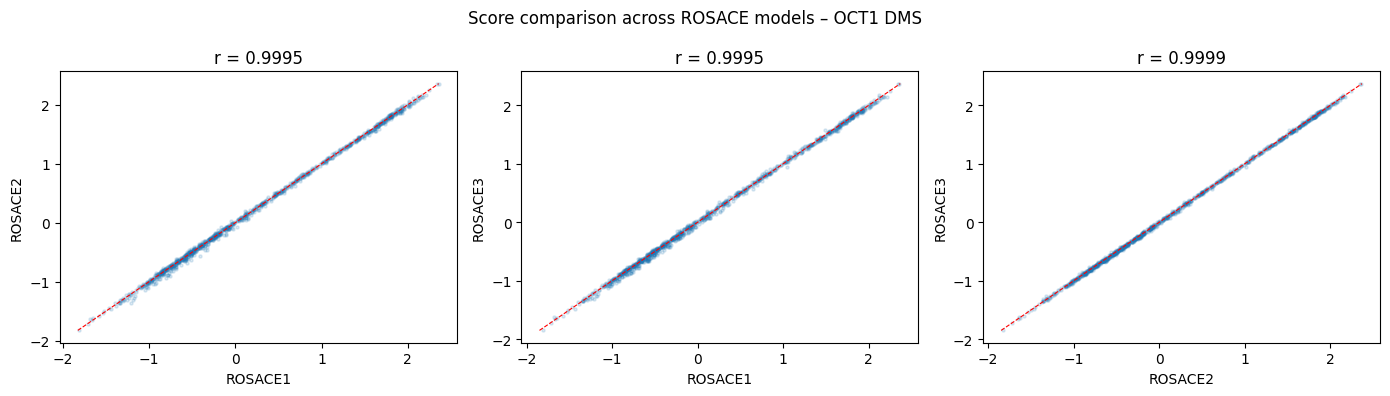

In [20]:
# Build a merged comparison on the missense variants (common to models 1/2/3)
compare = (
    scores_model1[["variant", "mean"]].rename(columns={"mean": "ROSACE1"})
    .merge(scores_model2[["variant", "mean"]].rename(columns={"mean": "ROSACE2"}),
           on="variant")
    .merge(scores_model3[["variant", "mean"]].rename(columns={"mean": "ROSACE3"}),
           on="variant")
)

r12 = compare[["ROSACE1", "ROSACE2"]].corr().iloc[0, 1]
r13 = compare[["ROSACE1", "ROSACE3"]].corr().iloc[0, 1]
r23 = compare[["ROSACE2", "ROSACE3"]].corr().iloc[0, 1]
print(f"Pearson r  ROSACE1 vs ROSACE2 : {r12:.4f}")
print(f"Pearson r  ROSACE1 vs ROSACE3 : {r13:.4f}")
print(f"Pearson r  ROSACE2 vs ROSACE3 : {r23:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [("ROSACE1", "ROSACE2", r12), ("ROSACE1", "ROSACE3", r13), ("ROSACE2", "ROSACE3", r23)]
for ax, (xc, yc, r) in zip(axes, pairs):
    ax.scatter(compare[xc], compare[yc], alpha=0.15, s=5)
    lim = [min(compare[xc].min(), compare[yc].min()),
           max(compare[xc].max(), compare[yc].max())]
    ax.plot(lim, lim, "r--", linewidth=0.8)
    ax.set_xlabel(xc)
    ax.set_ylabel(yc)
    ax.set_title(f"r = {r:.4f}")
fig.suptitle("Score comparison across ROSACE models – OCT1 DMS", fontsize=12)
plt.tight_layout()
plt.show()


## Position-level effects

For ROSACE1/2/3, `score.optional_score` contains the position-level mean effect `phi[p]` — equivalent to R's `OutputScore(pos.info = TRUE)$df_position`. Positions with strongly negative phi are likely functionally critical.


In [21]:
pos_scores = score_model1.optional_score.copy()
print(f"Position-level scores: {len(pos_scores)} positions")

print("\nTop 10 most negatively selected positions (phi):")
display(pos_scores.nsmallest(10, "mean").reset_index(drop=True))

print("\nTop 10 most positively selected positions (phi):")
display(pos_scores.nlargest(10, "mean").reset_index(drop=True))


Position-level scores: 53 positions

Top 10 most negatively selected positions (phi):


,pos,mean,sd
0,335,-0.898472,0.132735
1,83,-0.883007,0.148142
2,80,-0.777525,0.141780
3,315,-0.742001,0.133813
4,99,-0.712036,0.130397
5,67,-0.708051,0.129026
6,110,-0.629917,0.151223
7,21,-0.553119,0.158943
8,493,-0.549369,0.135795
9,520,-0.528221,0.134963



Top 10 most positively selected positions (phi):


,pos,mean,sd
0,142,1.854546,0.111935
1,121,1.797780,0.116200
2,102,1.759403,0.111725
3,33,1.481196,0.188929
4,255,1.233456,0.179230
5,170,1.110001,0.197546
6,506,1.087316,0.217293
7,383,1.013408,0.200062
8,237,0.864007,0.205086
9,298,0.846358,0.243601


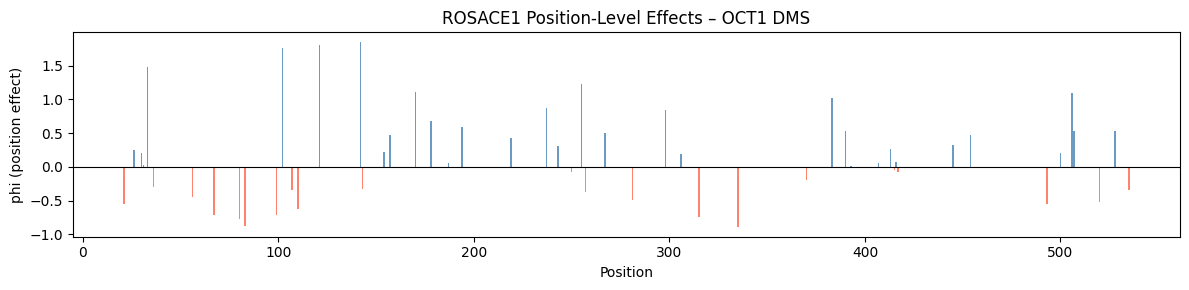

In [22]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(
    pos_scores["pos"], pos_scores["mean"],
    color=["steelblue" if m >= 0 else "tomato" for m in pos_scores["mean"]],
    width=0.8, alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Position")
ax.set_ylabel("phi (position effect)")
ax.set_title("ROSACE1 Position-Level Effects – OCT1 DMS")
plt.tight_layout()
plt.show()


## Top loss-of-function and gain-of-function variants

Use ROSACE1 scores (ROSACE2/3 are similar) to identify the most strongly deleterious and beneficial mutations.


In [23]:
scores_meta = scores_model1.merge(
    var_data.rename(columns={"variants": "variant"}), on="variant", how="left"
)
cols = ["variant", "position", "wildtype", "mutation", "mean", "sd", "lfsr", "label"]

print("Top 10 Loss-of-Function variants (most negative ROSACE1 score):")
display(scores_meta.nsmallest(10, "mean")[cols].reset_index(drop=True))

print("\nTop 10 Gain-of-Function variants (most positive ROSACE1 score):")
display(scores_meta.nlargest(10, "mean")[cols].reset_index(drop=True))


Top 10 Loss-of-Function variants (most negative ROSACE1 score):


,variant,position,wildtype,mutation,mean,sd,lfsr,label
0,p.(A31S),31.0,A,S,-1.810538,0.272038,1.411961e-11,Neg
1,p.(A335K),335.0,A,K,-1.712912,0.266850,6.858339e-11,Neg
2,p.(A393V),393.0,A,V,-1.680317,0.287794,2.631774e-09,Neg
3,p.(A83Q),83.0,A,Q,-1.664945,0.231005,2.851315e-13,Neg
4,p.(A83P),83.0,A,P,-1.649437,0.264328,2.186381e-10,Neg
5,p.(A390G),390.0,A,G,-1.577552,0.281491,1.045686e-08,Neg
6,p.(C36V),36.0,C,V,-1.531218,0.245301,2.157283e-10,Neg
7,p.(A99F),99.0,A,F,-1.520520,0.233849,3.959134e-11,Neg
8,p.(A30F),30.0,A,F,-1.465357,0.260691,9.489788e-09,Neg
9,p.(A187S),187.0,A,S,-1.438282,0.254551,8.009493e-09,Neg



Top 10 Gain-of-Function variants (most positive ROSACE1 score):


,variant,position,wildtype,mutation,mean,sd,lfsr,label
0,p.(A267D),267.0,A,D,2.358470,0.280025,1.844854e-17,Pos
1,p.(A33D),33.0,A,D,2.342047,0.250673,4.680293e-21,Pos
2,p.(A33K),33.0,A,K,2.249726,0.232388,1.817282e-22,Pos
3,p.(A31R),31.0,A,R,2.210499,0.276395,6.342448e-16,Pos
4,p.(A33I),33.0,A,I,2.173277,0.244327,2.922203e-19,Pos
5,p.(A506K),506.0,A,K,2.170015,0.261724,5.603523e-17,Pos
6,p.(A33M),33.0,A,M,2.169939,0.263563,9.121018e-17,Pos
7,p.(C142S),142.0,C,S,2.144310,0.214680,8.564307e-24,Pos
8,p.(C121V),121.0,C,V,2.135024,0.224689,1.028338e-21,Pos
9,p.(A33W),33.0,A,W,2.123158,0.243863,1.569144e-18,Pos


## Score distribution

Density plot of ROSACE1 scores for the missense variants.


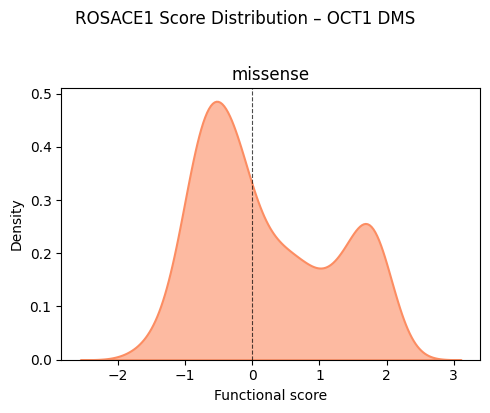

In [24]:
fig = score_density(
    data=scores_meta,
    type_col="type",
    score_col="mean",
    order=["missense"],
    title="ROSACE1 Score Distribution – OCT1 DMS",
    show=False,
)
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrated the full rosaceAA workflow on the **OCT1 DMS dataset**, replicating the [R vignette](https://github.com/pimentellab/rosace-aa/blob/main/vignettes/intro_rosaceAA.Rmd):

1. **Data loading** – `oct1.rda` read with `rdata`, three replicates converted to `AssayGrowth` objects.
2. **QC** – per-replicate filtering (`na_rmax=0.5, min_count=20`), KNN imputation, wildtype normalisation.
3. **Integration** – three replicates merged into a single `AssaySetGrowth` via outer join.
4. **Variant metadata** – HGVS names parsed into `position`, `wildtype`, `mutation`, `type`.
5. **Four ROSACE models** run via `run_rosace(method=...)`:
   - **ROSACE0** – baseline, no structural prior.
   - **ROSACE1** – position-level hierarchical shrinkage.
   - **ROSACE2** – position + global BLOSUM62 group (rosaceAA).
   - **ROSACE3** – ROSACE2 + per-position activation fraction `rho`.
6. **Score output** – variant-level `output_score()` and position-level `optional_score`.
7. **Visualisation** – cross-model correlation, position bar plots, score density.

**Python vs R differences:**

| Feature | R (`rosaceAA`) | Python (`rosace`) |
|---------|---------------|-------------------|
| Run on single replicate | `type = "Assay"` | Pass `AssayGrowth` to `run_rosace` |
| Run on all replicates | `type = "AssaySet"` | Pass `AssaySetGrowth` to `run_rosace` |
| `ctrl.col` / `stop.col` | Supported | Use `var_info` filtering instead |
| `OutputScore(blosum.info=TRUE)` | Returns BLOSUM group column | Derive from `var_info` + `map_blosum_score` |
| `OutputScore(pos.act.info=TRUE)` | Returns activation info | `rho` is a global scalar in the Stan model |
